# Online Retail — Data Analysis Project
**Dataset:** UCI Online Retail | Dec 2010 – Dec 2011  
**This notebook covers:** Data Cleaning · EDA · Visualizations


## 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi']     = 120
plt.rcParams['figure.figsize'] = (12, 5)


## 2. Load the Data

In [2]:
df = pd.read_csv(r"C:\Users\LOQ\Documents\STUDYING\DEPI\Technical\Global-Ecommerce-Project\DataSet\online_retail.csv")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()


Shape: 541,909 rows × 8 columns


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 3. Exploratory Data Analysis (EDA)

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [4]:
df.describe()


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [5]:
print("Missing values:")
print(df.isnull().sum())


Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [6]:
print(f"Duplicate rows          : {df.duplicated().sum():,}")
print(f"Cancelled invoices (C*) : {df['InvoiceNo'].astype(str).str.startswith('C').sum():,}")
print(f"Negative quantities     : {(df['Quantity'] < 0).sum():,}")
print(f"Zero or negative prices : {(df['UnitPrice'] <= 0).sum():,}")
print(f"Unique countries        : {df['Country'].nunique()}")
print(f"Date range              : {df['InvoiceDate'].min()} → {df['InvoiceDate'].max()}")


Duplicate rows          : 5,268
Cancelled invoices (C*) : 9,288
Negative quantities     : 10,624
Zero or negative prices : 2,517
Unique countries        : 38
Date range              : 2010-12-01 08:26:00 → 2011-12-09 12:50:00


## 4. Data Cleaning




In [7]:
df_clean = df.copy()

before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Duplicates removed      : {before - len(df_clean):,}")

before = len(df_clean)
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]
print(f"Cancellations removed   : {before - len(df_clean):,}")

before = len(df_clean)
df_clean = df_clean[df_clean['Quantity'] > 0]
print(f"Negative qty removed    : {before - len(df_clean):,}")

before = len(df_clean)
df_clean = df_clean[df_clean['UnitPrice'] > 0]
print(f"Bad prices removed      : {before - len(df_clean):,}")

before = len(df_clean)
df_clean = df_clean.dropna(subset=['Description'])
print(f"Missing desc removed    : {before - len(df_clean):,}")

df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['Description'] = df_clean['Description'].str.strip().str.title()
df_clean['Country']     = df_clean['Country'].str.strip()
df_clean['TotalSales']  = (df_clean['Quantity'] * df_clean['UnitPrice']).round(2)

print(f"\nFinal rows : {len(df_clean):,}  (kept {len(df_clean)/len(df)*100:.1f}%)")


Duplicates removed      : 5,268
Cancellations removed   : 9,251
Negative qty removed    : 1,336
Bad prices removed      : 1,176
Missing desc removed    : 0

Final rows : 524,878  (kept 96.9%)


In [8]:
# Add useful time columns
df_clean['Year']      = df_clean['InvoiceDate'].dt.year
df_clean['Month']     = df_clean['InvoiceDate'].dt.month
df_clean['MonthName'] = df_clean['InvoiceDate'].dt.strftime('%b')
df_clean['DayOfWeek'] = df_clean['InvoiceDate'].dt.day_name()
df_clean['Hour']      = df_clean['InvoiceDate'].dt.hour

df_clean.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales,Year,Month,MonthName,DayOfWeek,Hour
0,536365,85123A,White Hanging Heart T-Light Holder,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,Dec,Wednesday,8
1,536365,71053,White Metal Lantern,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,Dec,Wednesday,8
2,536365,84406B,Cream Cupid Hearts Coat Hanger,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,Dec,Wednesday,8
3,536365,84029G,Knitted Union Flag Hot Water Bottle,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,Dec,Wednesday,8
4,536365,84029E,Red Woolly Hottie White Heart.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,Dec,Wednesday,8


## 5. Visualizations

### 5.1 Monthly Revenue Trend

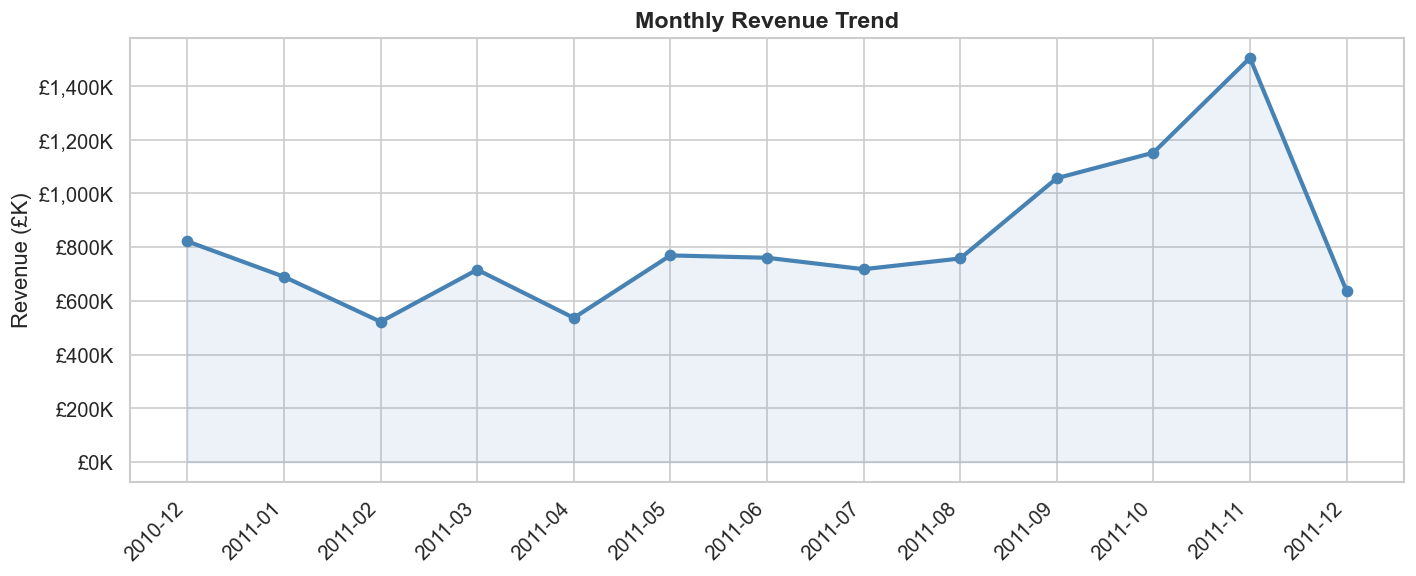

In [9]:
monthly = (df_clean.groupby(df_clean['InvoiceDate'].dt.to_period('M'))['TotalSales']
           .sum().reset_index())
monthly['InvoiceDate'] = monthly['InvoiceDate'].astype(str)

fig, ax = plt.subplots()
ax.plot(monthly['InvoiceDate'], monthly['TotalSales'] / 1000,
        marker='o', linewidth=2.5, color='steelblue')
ax.fill_between(monthly['InvoiceDate'], monthly['TotalSales'] / 1000, alpha=0.1, color='steelblue')
ax.set_title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
ax.set_ylabel('Revenue (£K)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:,.0f}K'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### 5.2 Top 10 Products by Revenue

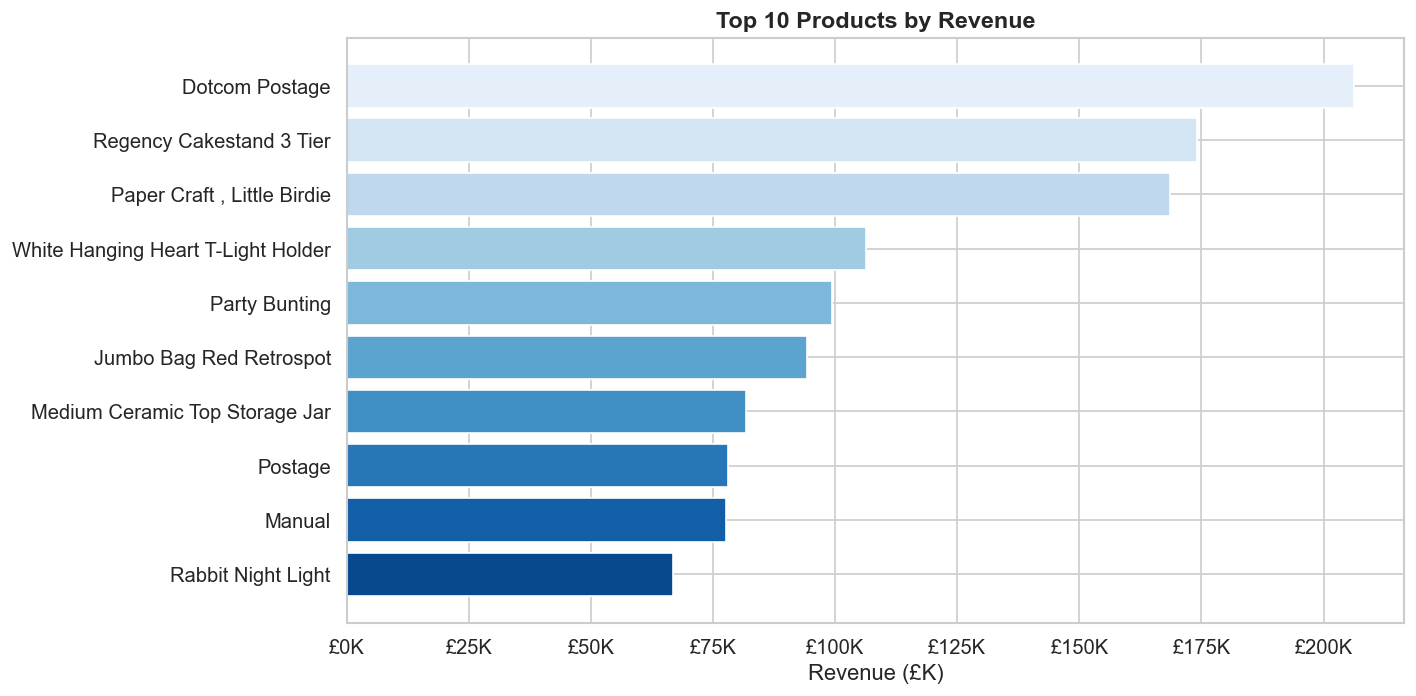

In [10]:
top_products = (df_clean.groupby('Description')['TotalSales']
                .sum().sort_values(ascending=False).head(10).reset_index())

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top_products['Description'][::-1],
        top_products['TotalSales'][::-1] / 1000,
        color=sns.color_palette('Blues_r', 10))
ax.set_title('Top 10 Products by Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Revenue (£K)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:,.0f}K'))
plt.tight_layout()
plt.show()


### 5.3 Revenue by Country (Excl. UK)

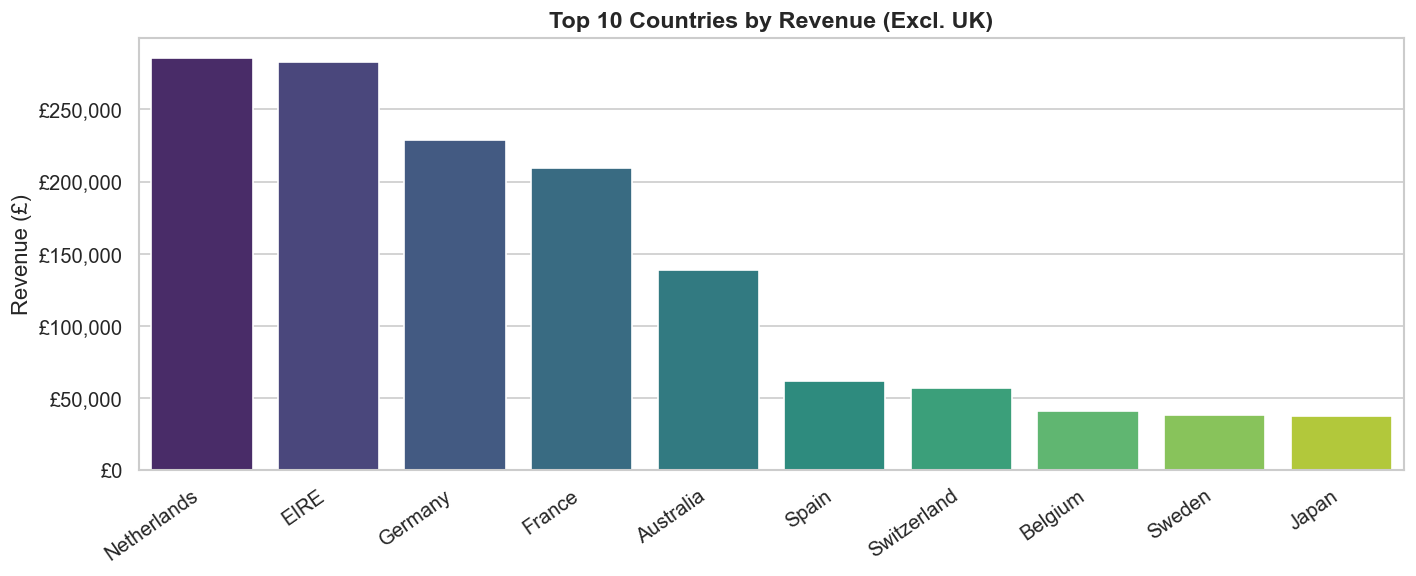

In [11]:
country_rev = (df_clean[df_clean['Country'] != 'United Kingdom']
               .groupby('Country')['TotalSales']
               .sum().sort_values(ascending=False).head(10).reset_index())

fig, ax = plt.subplots()
sns.barplot(data=country_rev, x='Country', y='TotalSales', palette='viridis', ax=ax)
ax.set_title('Top 10 Countries by Revenue (Excl. UK)', fontsize=14, fontweight='bold')
ax.set_ylabel('Revenue (£)')
ax.set_xlabel('')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:,.0f}'))
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()


### 5.4 Revenue by Day of Week

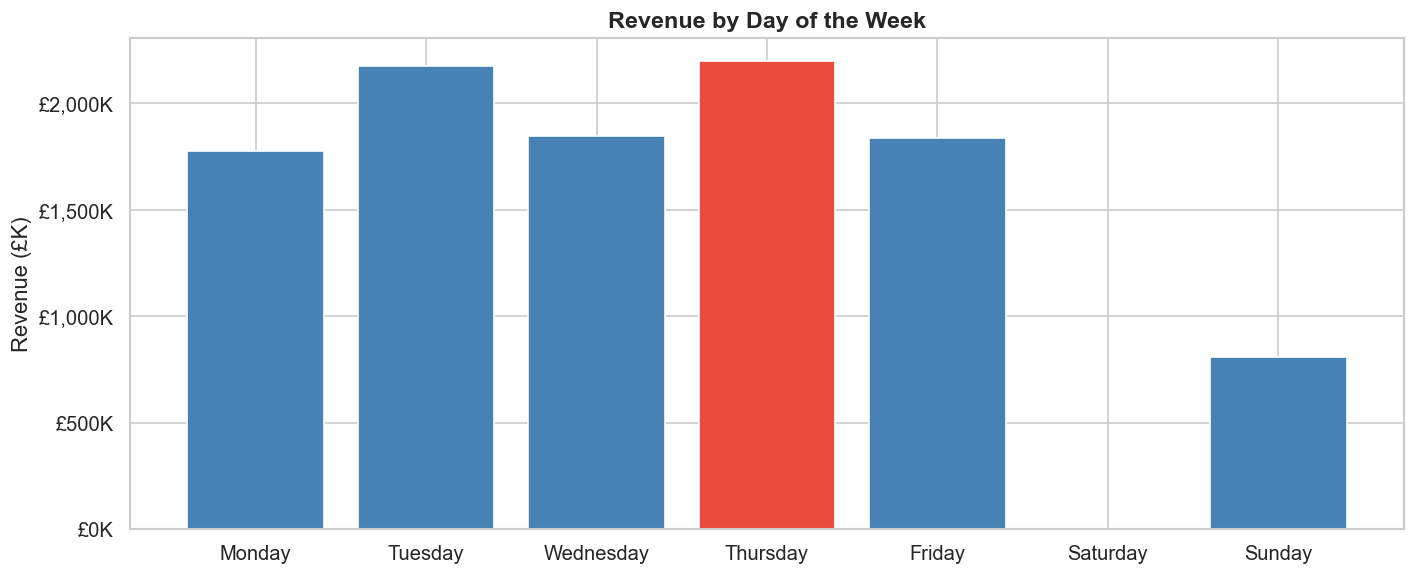

In [12]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_sales = df_clean.groupby('DayOfWeek')['TotalSales'].sum().reindex(day_order).reset_index()
peak      = day_sales.loc[day_sales['TotalSales'].idxmax(), 'DayOfWeek']
colors    = ['#e74c3c' if d == peak else 'steelblue' for d in day_sales['DayOfWeek']]

fig, ax = plt.subplots()
ax.bar(day_sales['DayOfWeek'], day_sales['TotalSales'] / 1000, color=colors, edgecolor='white')
ax.set_title('Revenue by Day of the Week', fontsize=14, fontweight='bold')
ax.set_ylabel('Revenue (£K)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:,.0f}K'))
plt.tight_layout()
plt.show()


### 5.5 Revenue by Hour of Day

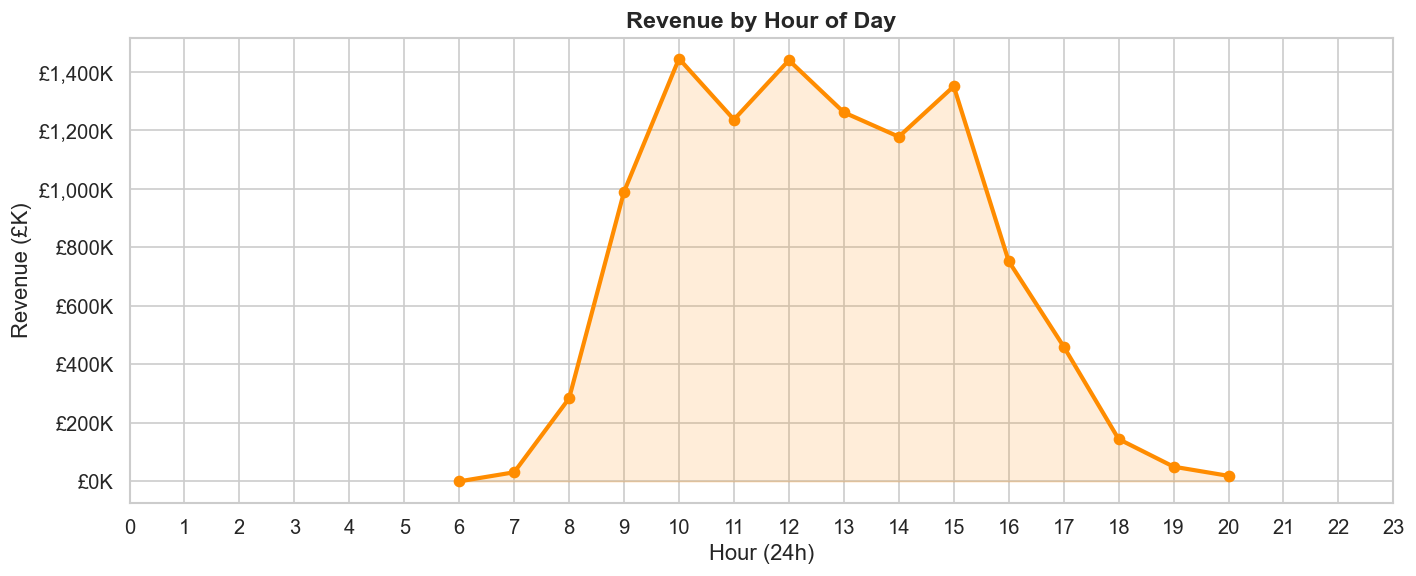

In [13]:
hour_sales = df_clean.groupby('Hour')['TotalSales'].sum().reset_index()

fig, ax = plt.subplots()
ax.plot(hour_sales['Hour'], hour_sales['TotalSales'] / 1000,
        marker='o', color='darkorange', linewidth=2.5)
ax.fill_between(hour_sales['Hour'], hour_sales['TotalSales'] / 1000, alpha=0.15, color='darkorange')
ax.set_title('Revenue by Hour of Day', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour (24h)')
ax.set_ylabel('Revenue (£K)')
ax.set_xticks(range(0, 24))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:,.0f}K'))
plt.tight_layout()
plt.show()


### 5.6 Transaction Value Distribution

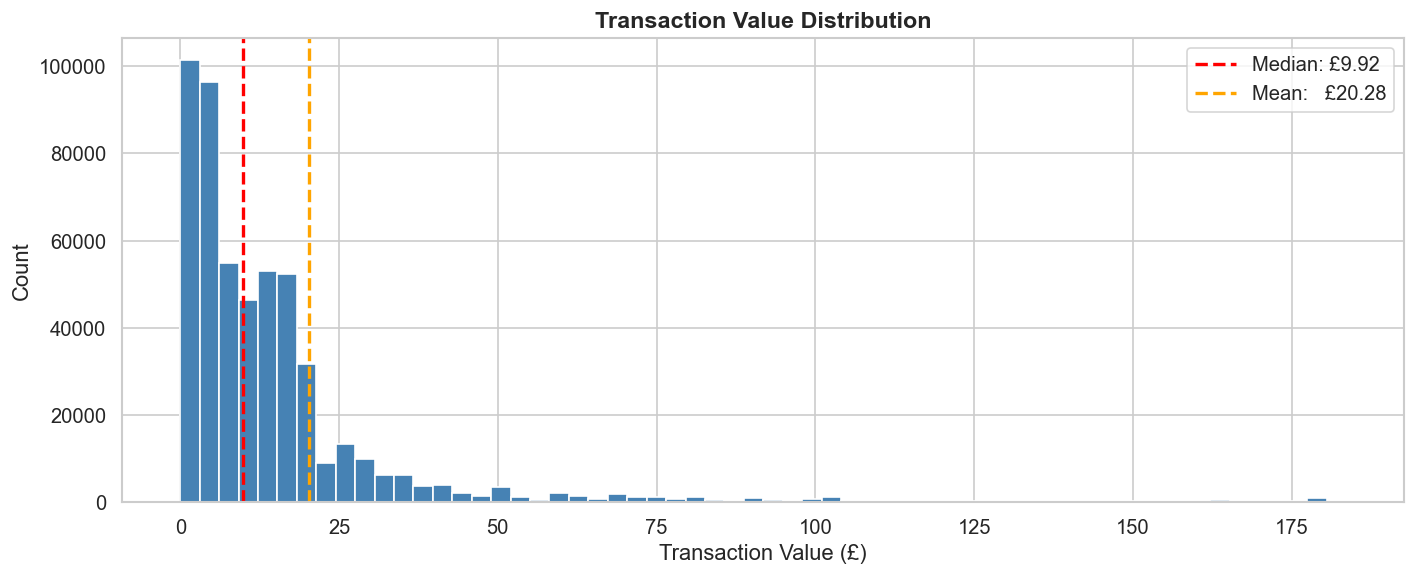

In [14]:
cap = df_clean['TotalSales'].quantile(0.99)
ts  = df_clean[df_clean['TotalSales'] <= cap]['TotalSales']

fig, ax = plt.subplots()
ax.hist(ts, bins=60, color='steelblue', edgecolor='white')
ax.axvline(df_clean['TotalSales'].median(), color='red',    linestyle='--', linewidth=2,
           label=f"Median: £{df_clean['TotalSales'].median():.2f}")
ax.axvline(df_clean['TotalSales'].mean(),   color='orange', linestyle='--', linewidth=2,
           label=f"Mean:   £{df_clean['TotalSales'].mean():.2f}")
ax.set_title('Transaction Value Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Transaction Value (£)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()


## 6. Export Cleaned Data

In [15]:
df_clean.to_csv(r"C:\Users\LOQ\Documents\STUDYING\DEPI\Technical\Global-Ecommerce-Project\final-proj\cleaned_data.csv", index=False)
print(f"Saved: online_retail_cleaned.csv  ({len(df_clean):,} rows)")


Saved: online_retail_cleaned.csv  (524,878 rows)
